Compare repetition-centered lag-CRP curves for observed data and a matched control dataset.

Adjust `ctrl_query` to define alternative control populations.

Set `repetition_index` to 0 or 1 to focus on specific presentations.

In [1]:
import os

from jaxcmr.analyses.repcrp import plot_rep_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset


In [2]:
data_name = "LohnasKahana2014"
data_query = "data['list_type'] == 4"
ctrl_query = "data['list_type'] == 1"
min_lag = 4


In [3]:
project_root = find_project_root()
data_path = os.path.join(project_root, 'data', f'{data_name}.h5')
data = load_data(data_path)
trial_mask = generate_trial_mask(data, data_query)
control_dataset = make_control_dataset(data, data_query, ctrl_query, 10)
control_mask = generate_trial_mask(control_dataset, data_query)
datasets = [data, control_dataset]
masks = [trial_mask, control_mask]


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


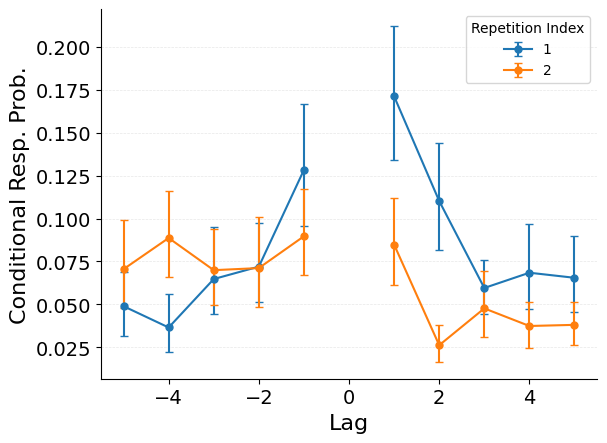

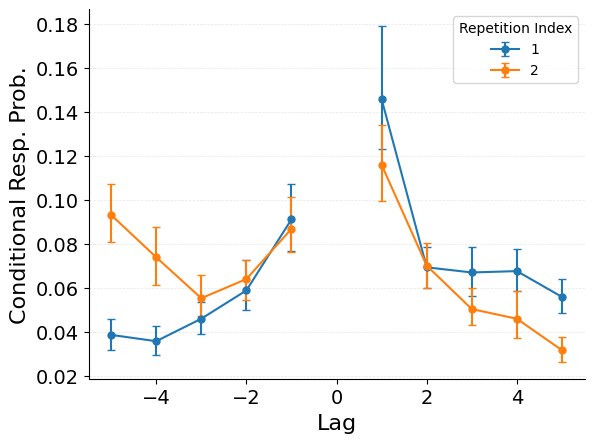

In [4]:
plot_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    min_lag=min_lag,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
plot_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    min_lag=min_lag,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
);


In [5]:
import numpy as np
from jax import jit
from scipy import stats

from jaxcmr.analyses.repcrp import repcrp
from jaxcmr.helpers import apply_by_subject

# Parameters
max_lag = 5
size = 2

# Compute subject-level CRP values for observed and control datasets
observed_subject_values = apply_by_subject(
    data, trial_mask, jit(repcrp, static_argnames=("size",)), min_lag, size
)
control_subject_values = apply_by_subject(
    control_dataset, control_mask, jit(repcrp, static_argnames=("size",)), min_lag, size
)

# Get lag range from data
lag_range = int(np.max(data["listLength"][trial_mask])) - 1
lag_slice = slice(lag_range - max_lag, lag_range + max_lag + 1)
lag_labels = np.arange(-max_lag, max_lag + 1)

# Stack subject values and slice to lag range of interest
# Shape: [n_subjects, n_repetition_indices, n_lags]
for rep_idx, rep_label in enumerate(["First Presentation", "Second Presentation"]):
    observed_crp = np.vstack([s[rep_idx, lag_slice] for s in observed_subject_values])
    control_crp = np.vstack([s[rep_idx, lag_slice] for s in control_subject_values])

    print(f"\n{'='*60}")
    print(f"Statistical Tests: {rep_label}")
    print(f"{'='*60}")
    print(f"{'Lag':>5} | {'t-stat':>8} {'t p-val':>10} | {'W-stat':>8} {'W p-val':>10}")
    print(f"{'-'*5}-+-{'-'*20}-+-{'-'*20}")

    for lag_idx, lag in enumerate(lag_labels):
        obs = observed_crp[:, lag_idx]
        ctrl = control_crp[:, lag_idx]
        diff = obs - ctrl

        # Paired t-test
        t_stat, t_pval = stats.ttest_rel(obs, ctrl, nan_policy='omit')

        # Wilcoxon signed-rank test (handles NaN by removing pairs)
        valid = ~(np.isnan(obs) | np.isnan(ctrl))
        if valid.sum() > 10:
            w_stat, w_pval = stats.wilcoxon(diff[valid], alternative='two-sided')
        else:
            w_stat, w_pval = np.nan, np.nan

        print(f"{lag:>5} | {t_stat:>8.3f} {t_pval:>10.4f} | {w_stat:>8.1f} {w_pval:>10.4f}")


Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val
------+----------------------+---------------------
   -5 |    0.953     0.3473 |    315.0     1.0000
   -4 |    0.087     0.9315 |    268.0     0.6140
   -3 |    1.443     0.1582 |    235.0     0.2853
   -2 |    1.268     0.2133 |    251.0     0.3023
   -1 |    2.266     0.0299 |    204.0     0.0700
    0 |      nan        nan |      nan        nan
    1 |    1.594     0.1201 |    222.0     0.1310
    2 |    2.480     0.0182 |    196.0     0.0515
    3 |   -0.874     0.3884 |    267.0     0.4413
    4 |    0.062     0.9512 |    233.0     0.3960
    5 |    0.847     0.4032 |    282.0     0.5988

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val
------+----------------------+---------------------
   -5 |   -1.622     0.1140 |    166.0     0.0246
   -4 |    1.129     0.2668 |    263.0     0.4036
   -3 |    1.293     0.2046 |    254.0     0.3259
   -2 |    0.517 

/var/folders/7n/m1dxq2r12b77t0c09mty9kn00000gn/T/ipykernel_1721/2940122538.py:43: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs, ctrl, nan_policy='omit')
